🧬 01_Gene_to_Protein Notebook: From APOE Gene to Protein

🧠 APOE apolipoprotein E [ Homo sapiens (human) ] 


### ⭐ 1. Introduction

Question 
- What is the APOE gene, where is it located, and what protein does it encode?
  


APOE (Apolipoprotein E) is involved in lipid transport and is strongly associated with Alzheimer's disease.

Steps in this notebook:
1. Get gene information manually from NCBI
2. Download FASTA sequence
3. Analyze sequence (length, GC%, Nucleotides Frequency)
4. Transcribe (DNA to RNA) and translate (RNA to Protein)
5. Analyze protein properties


---

### ⭐ 2. Import Required Libraries

In [7]:
import pandas as pd

from Bio import Entrez                     # Entrez can actually handles messages between our computer and the NCBI database.

from Bio import SeqIO

Entrez.email = "sahelsepehri99@gmail.com"  # We sould tell NCBI who we are so we won't being blocked.


---


### ⭐ 3. Biological and Database Exploration of APOE

Retrieving APOE gene from NCBI


[NCBI - APOE Page](https://www.ncbi.nlm.nih.gov/gene/?term=APOE)


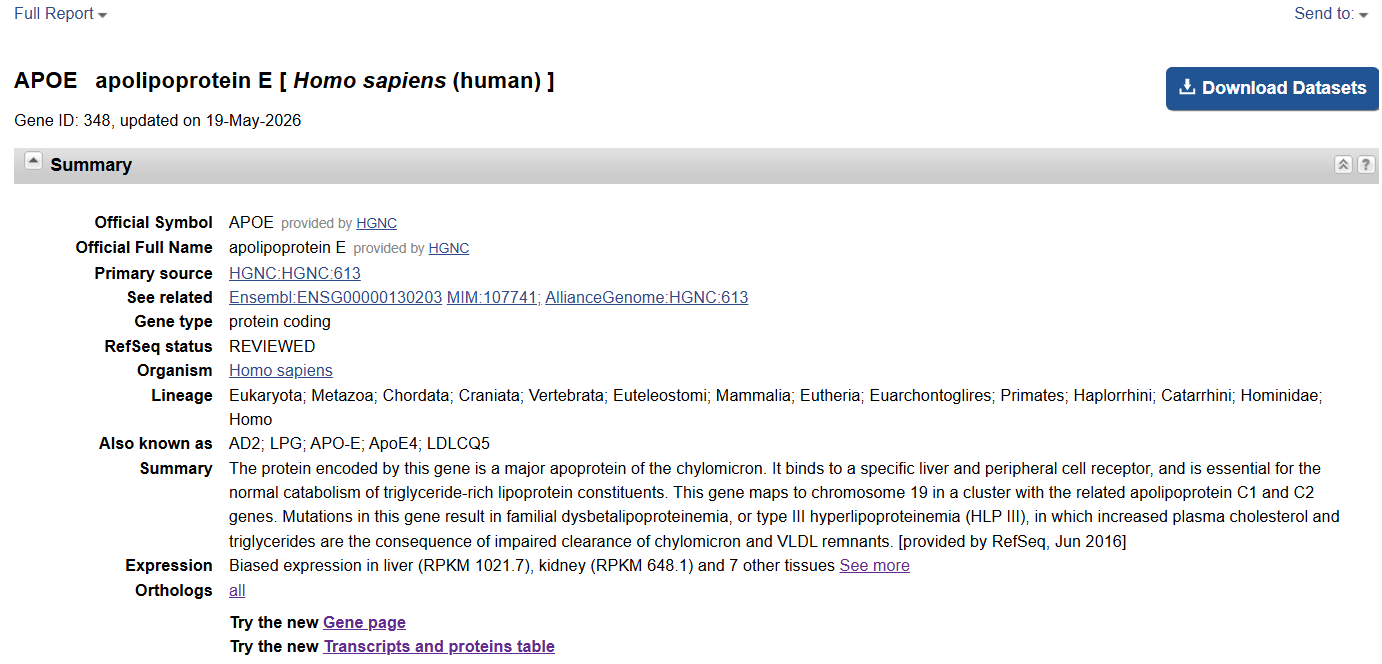

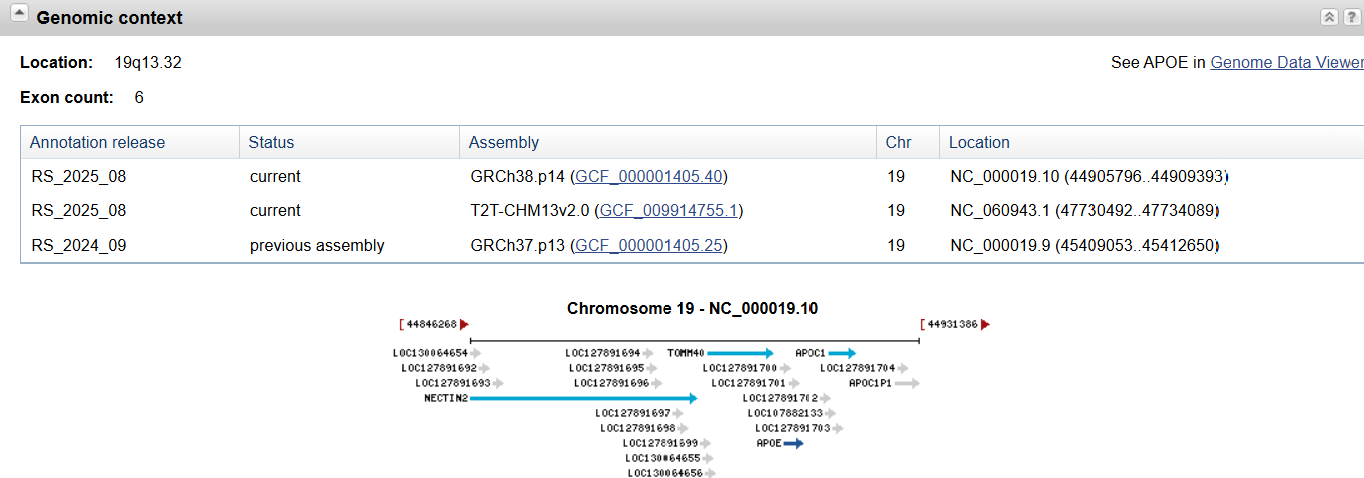

In [2]:
apoe_human_info = {
    "Gene Symbol" : "APOE",
    "Official Full Name" : "apolipoprotein E",
    "NCBI Gene ID" : "348",
    "Gene type" : "protein coding",
    "Ensembl ID" : "ENSG00000130203",
    "HGNC ID" : "HGNC:613",
    "Other Names" : "AD2, LPG, APO-E, ApoE4, LDLCQ5",
    "Organism" : "Homo sapiens",
    "Protein Isoforms" : "5",
    "Transcripts Counts" : "5",
    "Chromosome": "19",
    "Location": "19q13.32",
    "Exon count": "6",
    "Intron count" : "5"  #Exon - 1
}

In [3]:
df = pd.DataFrame(list(apoe_human_info.items()), columns= ["Identifier Type", "Value"])

df.style

,Identifier Type,Value
0,Gene Symbol,APOE
1,Official Full Name,apolipoprotein E
2,NCBI Gene ID,348
3,Gene type,protein coding
4,Ensembl ID,ENSG00000130203
5,HGNC ID,HGNC:613
6,Other Names,"AD2, LPG, APO-E, ApoE4, LDLCQ5"
7,Organism,Homo sapiens
8,Protein Isoforms,5
9,Transcripts Counts,5


---

### ⭐ 4. Reproducing Manual Findings Programmically

4.1 Gene ID

In [4]:
search_handle = Entrez.esearch(
    db= "gene",
    term = "APOE[Gene] AND Homo sapiens [Organism]"
)

search_record = Entrez.read(search_handle)
gene_id = search_record ["IdList"][0]
print(f" APOE Gene ID: {gene_id}")

 APOE Gene ID: 348


---
4.2 Gene Summary

In [5]:
handle = Entrez.esummary(
    db="gene",
    id=gene_id,
    retmode="xml"
)

summary = Entrez.read(handle)

doc = summary["DocumentSummarySet"]["DocumentSummary"][0]


data = {
    "Gene Name": doc["Name"],
    "Description": doc["Description"],
    "Chromosome": doc["Chromosome"],
    "Map Location": doc["MapLocation"],
    "Aliases": doc["OtherAliases"]
}

df = pd.DataFrame([data])
df



,Gene Name,Description,Chromosome,Map Location,Aliases
0,APOE,apolipoprotein E,19,19q13.32,"AD2, APO-E, ApoE4, LDLCQ5, LPG"


---

### mRNA
NM_000041.4

<div style="text-align: center;">
    <img src="Images/mrna_seq.png" alt="mRNA" style="width: 400px; border: 1px solid #ddd; border-radius: 5px;">
    <p><em>Figure 3: APOE mRNA sequence from NCBI</em></p>
</div>

In [20]:
# Fetch means " to go and get something or someone and bring them back"
# We ask NCBI to fetch a specific mRNA ID and save the connection handle
# id="NM_000041.4" -> id number for APOE main mRNA
# rettype="fasta" -> brings a protein in FASTA format. 
# retmode = "text" -> returns a simple text format (FASTA) instead of XML 

handle = Entrez.efetch(
    db="nucleotide",
    id="NM_000041.4",
    rettype="fasta",
    retmode="text"
)

mrna_record = SeqIO.read(handle, "fasta")

# Pull the text data out of the connection handle stream

print(mrna_record.description)

print("Sequence length:", len(mrna_record.seq))
print("\nFirst 100 characters of FASTA:")
print(mrna_record.seq[:100])


SeqIO.write(mrna_record, "APOE_mRNA.fasta", "fasta")

NM_000041.4 Homo sapiens apolipoprotein E (APOE), transcript variant 2, mRNA
Sequence length: 1166

First 100 characters of FASTA:
CTACTCAGCCCCAGCGGAGGTGAAGGACGTCCTTCCCCAGGAGCCGACTGGCCAATCACAGGCAGGAAGATGAAGGTTCTGTGGGCTGCGTTGCTGGTCA


1

---

### Protein 
>NP_000032.1

[Analyzing protein sequences with the ProtParam module](https://biopython.org/wiki/ProtParam)

- RNA title:	mRNA-apolipoprotein E, transcript variant 2
-
- 
- Merged features: NM_000041.4 and NP_000032.1
- Location:	44,905,796..44,909,393	
- Span on NC_000019.10: 3,598 nt
- Aligned length:	1,166 nt
- CDS length:	954 nt



- mRNA RefSeq : NM_000041.4



Transcript variants
Protein isoforms
Gene length

- Protein title :	apolipoprotein E isoform b precursor
- Protein comment:	isoform b precursor is encoded by transcript variant 2
- Protein length:	317 aa
- Protein Refseq : NP_000032.1
- Protein Function : 



---

References 

- [NCBI](https://www.ncbi.nlm.nih.gov/)
- [Pandas Documentation](https://pandas.pydata.org/docs/index.html)
- [Accessing NCBI’s Entrez databases - biopython](https://biopython.org/docs/latest/Tutorial/chapter_entrez.html)
- [ClinVar](https://www.ncbi.nlm.nih.gov/clinvar/)
- [BLAST](https://blast.ncbi.nlm.nih.gov/)

The APOE gene information was first explored manually using NCBI database.
Then the same Information was programmically retrieved using Biopython (ENTREZ API) to validate reproducibility.

